<a href="https://colab.research.google.com/github/Sravani-939/genai-training-tasks/blob/main/DigitsTask_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
#loads a famous dataset called MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape) #img size (inp)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)


In [4]:
#data preprocessing
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [5]:
#CNN model -> layers added 1 by 1
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)), #reduce size of img

    keras.layers.Flatten(), #2d img to 1d vector

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam', #updates model weights during training
    loss='sparse_categorical_crossentropy', # Measures how wrong the prediction is
    metrics=['accuracy'] #shows how many predictions are correct
)

In [10]:
model.fit(x_train, y_train, epochs=10) #training the model by data 10tyms

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9615 - loss: 0.1274
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9871 - loss: 0.0426
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9907 - loss: 0.0294
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9938 - loss: 0.0202
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9946 - loss: 0.0162
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9962 - loss: 0.0115
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9966 - loss: 0.0099
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9976 - loss: 0.0073
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9976 - loss: 0.0075
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9980 - loss: 0.0062


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0355
Test Accuracy: 0.9908000230789185


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted: 4
Actual: 4


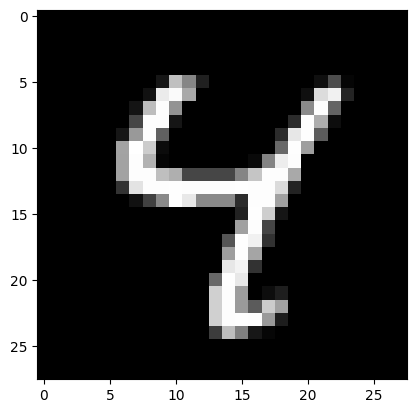

In [12]:
predictions = model.predict(x_test) #prediction starts for every img
i=6 #chooses index 6th img
plt.imshow(x_test[i].reshape(28,28), cmap='gray')
print("Predicted:", np.argmax(predictions[i])) #predicts highest index value
print("Actual:", y_test[i])
plt.show()

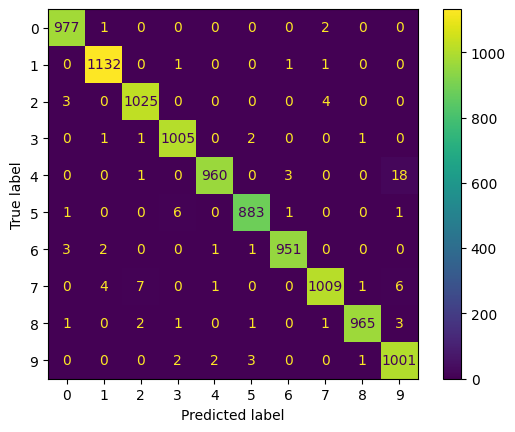

In [13]:
y_pred_classes = np.argmax(predictions, axis=1)  #if diagonal its correct if not confusing nums

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()